# So sánh Resource Idle Time giữa các models

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Hàm 1: Tính Resource Idle Time cho một model

In [2]:
def calculate_resource_idle_time(model_name, num_patients=200):
    """
    Tính resource idle time cho một model cụ thể.
    
    Args:
        model_name: Tên model (e.g., 'Random', 'DQN', 'FORLAPS', etc.)
        num_patients: Số lượng bệnh nhân
    
    Returns:
        tuple: (idle_time_per_activity, avg_idle_time_per_resource)
            - idle_time_per_activity: list of 21 floats (idle time for each activity)
            - avg_idle_time_per_resource: float (average idle time per resource)
    """
    # Load activity info to get resource counts
    activity_info_path = os.path.join('..', 'data', 'raw', 'activity_info.json')
    with open(activity_info_path, 'r', encoding='utf-8') as f:
        activity_info = json.load(f)
    
    # Get activity names in order (id 1-21)
    id_to_name = {info['id']: name for name, info in activity_info.items()}
    activity_names = [id_to_name[i] for i in range(1, 22)]
    
    # Extract resource counts as a vector (21 activities)
    resource_counts = np.array([activity_info[name]['staff'] for name in activity_names])
    
    # Determine queue log file path based on model name
    raw_data_dir = os.path.join('..', 'data', 'raw')
    
    if model_name == 'Random':
        queue_log_path = os.path.join(raw_data_dir, f'queue_log_{num_patients}_Random_gen_0.csv')
    elif model_name in ['FORLAPS', 'LearningToAct']:
        queue_log_path = os.path.join(raw_data_dir, f'queue_log_{num_patients}_{model_name}.csv')
    else:
        # DQN-based models: find highest generation
        pattern = os.path.join(raw_data_dir, f'queue_log_{num_patients}_{model_name}_gen_*.csv')
        matching_files = glob(pattern)
        
        if not matching_files:
            print(f"⚠️ No queue log found for {model_name} with {num_patients} patients")
            return None, None
        
        # Extract generation numbers and find max
        import re
        gen_numbers = []
        for file in matching_files:
            match = re.search(r'_gen_(\d+)\.csv$', file)
            if match:
                gen_numbers.append((int(match.group(1)), file))
        
        if not gen_numbers:
            print(f"⚠️ Could not parse generation numbers for {model_name}")
            return None, None
        
        # Get file with highest generation
        gen_numbers.sort(reverse=True)
        queue_log_path = gen_numbers[0][1]
    
    # Check if file exists
    if not os.path.exists(queue_log_path):
        print(f"⚠️ Queue log not found: {queue_log_path}")
        return None, None
    
    # Load queue log
    df = pd.read_csv(queue_log_path)
    
    # Drop Time column to get only queue counts
    queue_data = df.drop(columns=['Time']).values  # Shape: (num_timesteps, 21)
    
    # Calculate idle resources at each timestep
    # idle = max(resource - queue, 0)
    idle_matrix = np.maximum(resource_counts - queue_data, 0)  # Shape: (num_timesteps, 21)
    
    # Sum across time to get total idle time per activity
    idle_time_per_activity = idle_matrix.sum(axis=0)  # Shape: (21,)
    
    # Sum across all activities and timesteps to get total idle time
    total_idle_time = idle_matrix.sum()
    
    # Calculate average idle time per resource
    total_resources = resource_counts.sum()
    avg_idle_time_per_resource = total_idle_time / total_resources if total_resources > 0 else 0
    
    return idle_time_per_activity.tolist(), avg_idle_time_per_resource

## Hàm 2: Tổng hợp kết quả cho tất cả models

In [3]:
def aggregate_idle_time_stats(num_patients=200):
    """
    Tính toán và tổng hợp resource idle time cho tất cả models.
    
    Args:
        num_patients: Số lượng bệnh nhân
    
    Returns:
        pd.DataFrame: Bảng so sánh với columns [Model, Resource Idle Time, Improve (%)]
    """
    all_models = ['Random', 'DQN', 'DDQN', 'Dueling', 'Rainbow', 'PerDQN', 'MultiStepDQN', 'FORLAPS', 'LearningToAct']
    
    # Load activity info for activity names
    activity_info_path = os.path.join('..', 'data', 'raw', 'activity_info.json')
    with open(activity_info_path, 'r', encoding='utf-8') as f:
        activity_info = json.load(f)
    
    id_to_name = {info['id']: name for name, info in activity_info.items()}
    activity_names = [id_to_name[i] for i in range(1, 22)]
    
    results = {}
    random_baseline_idle = None
    
    print(f"\n{'='*80}")
    print(f"RESOURCE IDLE TIME CHO {num_patients} BỆNH NHÂN")
    print(f"{'='*80}\n")
    
    for model in all_models:
        idle_per_activity, avg_idle = calculate_resource_idle_time(model, num_patients)
        
        if idle_per_activity is None or avg_idle is None:
            continue
        
        results[model] = {
            'idle_per_activity': idle_per_activity,
            'avg_idle': avg_idle
        }
        
        if model == 'Random':
            random_baseline_idle = avg_idle
        
        # Print idle time per activity
        print(f"📊 {model}:")
        print(f"   Average Idle Time per Resource: {avg_idle:.2f}")
        print(f"   Idle Time per Activity:")
        for i, (activity, idle_time) in enumerate(zip(activity_names, idle_per_activity)):
            print(f"      {activity:35s}: {idle_time:8.2f}")
        print()
    
    # Create summary DataFrame
    models_list = []
    idle_times = []
    improvements = []
    
    for model in all_models:
        if model not in results:
            continue
        
        models_list.append(model)
        avg_idle = results[model]['avg_idle']
        idle_times.append(avg_idle)
        
        # Calculate improvement (lower idle time is better, so improvement is negative of percentage change)
        if model == 'Random':
            improvements.append(0.0)
        elif random_baseline_idle and random_baseline_idle > 0:
            # Improvement: (baseline - current) / baseline * 100
            # If current < baseline, improvement is positive (good)
            improve = ((random_baseline_idle - avg_idle) / random_baseline_idle) * 100
            improvements.append(improve)
        else:
            improvements.append(np.nan)
    
    df = pd.DataFrame({
        'Model': models_list,
        'Resource Idle Time': idle_times,
        'Improve (%)': improvements
    })
    
    return df

## Hàm 3: Visualization và lưu PDF

In [4]:
def visualize_idle_time_comparison(num_patients=200):
    """
    Tạo visualization so sánh resource idle time và lưu thành PDF.
    
    Args:
        num_patients: Số lượng bệnh nhân
    """
    df = aggregate_idle_time_stats(num_patients)
    
    print(f"\n{'='*80}")
    print(f"BẢNG TỔNG HỢP RESOURCE IDLE TIME")
    print(f"{'='*80}")
    print(df.to_string(index=False))
    print()
    
    # === GENERATE PLOTS ===
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: Resource Idle Time comparison
    ax1 = axes[0]
    models = df['Model'].values
    idle_times = df['Resource Idle Time'].values
    
    # Pastel colors: Random in gray, DQN-based in pastel blue shades, offline in pastel orange/green
    pastel_colors = ['#B0B0B0',  # Gray for Random
                     '#AEC6CF', '#B4D7E8', '#C9E4F5', '#A8D8EA', '#B5D8EB', '#C2E0F0',  # Pastel blues for DQN-based
                     '#FFD1A4', '#B8E6B8']  # Pastel orange and green for FORLAPS and LearningToAct
    
    # Adjust colors based on actual models present
    color_map = {
        'Random': '#B0B0B0',
        'DQN': '#AEC6CF',
        'DDQN': '#B4D7E8',
        'Dueling': '#C9E4F5',
        'Rainbow': '#A8D8EA',
        'PerDQN': '#B5D8EB',
        'MultiStepDQN': '#C2E0F0',
        'FORLAPS': '#FFD1A4',
        'LearningToAct': '#B8E6B8'
    }
    colors = [color_map.get(m, '#B0B0B0') for m in models]
    
    bars1 = ax1.bar(range(len(models)), idle_times, color=colors, alpha=0.9, edgecolor='black', linewidth=1.2)
    ax1.set_xticks(range(len(models)))
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.set_ylabel('Resource Idle Time (minutes)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Resource Idle Time Comparison ({num_patients} patients)', fontsize=14, fontweight='bold', pad=20)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars1, idle_times)):
        if not np.isnan(val):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(idle_times)*0.01, 
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Plot 2: Improvement percentage
    ax2 = axes[1]
    improvements = df['Improve (%)'].values
    
    # Pastel colors based on positive/negative improvement
    bar_colors = []
    for model, imp in zip(models, improvements):
        if model == 'Random':
            bar_colors.append('#B0B0B0')  # Gray for Random
        elif imp > 0:
            bar_colors.append('#F7F284')  # Pastel yellow for positive (reduced idle time)
        elif imp < 0:
            bar_colors.append('#FFB6C1')  # Pastel red/pink for negative (increased idle time)
        else:
            bar_colors.append('#B0B0B0')  # Gray for neutral
    
    bars2 = ax2.bar(range(len(models)), improvements, color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.2)
    ax2.set_xticks(range(len(models)))
    ax2.set_xticklabels(models, rotation=45, ha='right')
    ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Idle Time Reduction ({num_patients} patients)', fontsize=14, fontweight='bold', pad=20)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='y', alpha=0.3)
    
    min_improve = np.nanmin(improvements)
    max_improve = np.nanmax(improvements)
    lower_bound = min(0, min_improve) - 2
    upper_bound = max(0, max_improve) + 2
    ax2.set_ylim(lower_bound, upper_bound)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars2, improvements)):
        if not np.isnan(val):
            offset = 0.6 if val >= 0 else -0.6
            ha = 'center'
            va = 'bottom' if val >= 0 else 'top'
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, 
                    f'{val:+.1f}%', ha=ha, va=va, 
                    fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure as PDF
    output_path = f'idle_time_comparison_{num_patients}_patients.pdf'
    plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
    print(f"\n✅ Đã lưu biểu đồ: {output_path}\n")
    
    plt.show()
    
    return df

## Chạy phân tích cho 200, 250, 300 bệnh nhân


RESOURCE IDLE TIME CHO 200 BỆNH NHÂN

📊 Random:
   Average Idle Time per Resource: 619.76
   Idle Time per Activity:
      Registration                       :  2950.00
      Payment                            :  1259.00
      Get Triage Number                  :   836.00
      Measure Vital Signs                :  2111.00
      General Medicine Examination       :  2752.00
      Eye Examination                    :  1067.00
      ENT Examination                    :  1072.00
      Dental Examination                 :  1079.00
      Gynecological Examination          :  1307.00
      Breast Examination                 :  1218.00
      Blood Test                         :  3188.00
      Urine Test                         :   684.00
      In-depth Eye Examination           :   836.00
      ENT Endoscopy                      :   836.00
      Electrocardiogram (ECG)            :  2508.00
      Post-bronchodilator Spirometry     :   836.00
      General Ultrasound                 :  1735.0

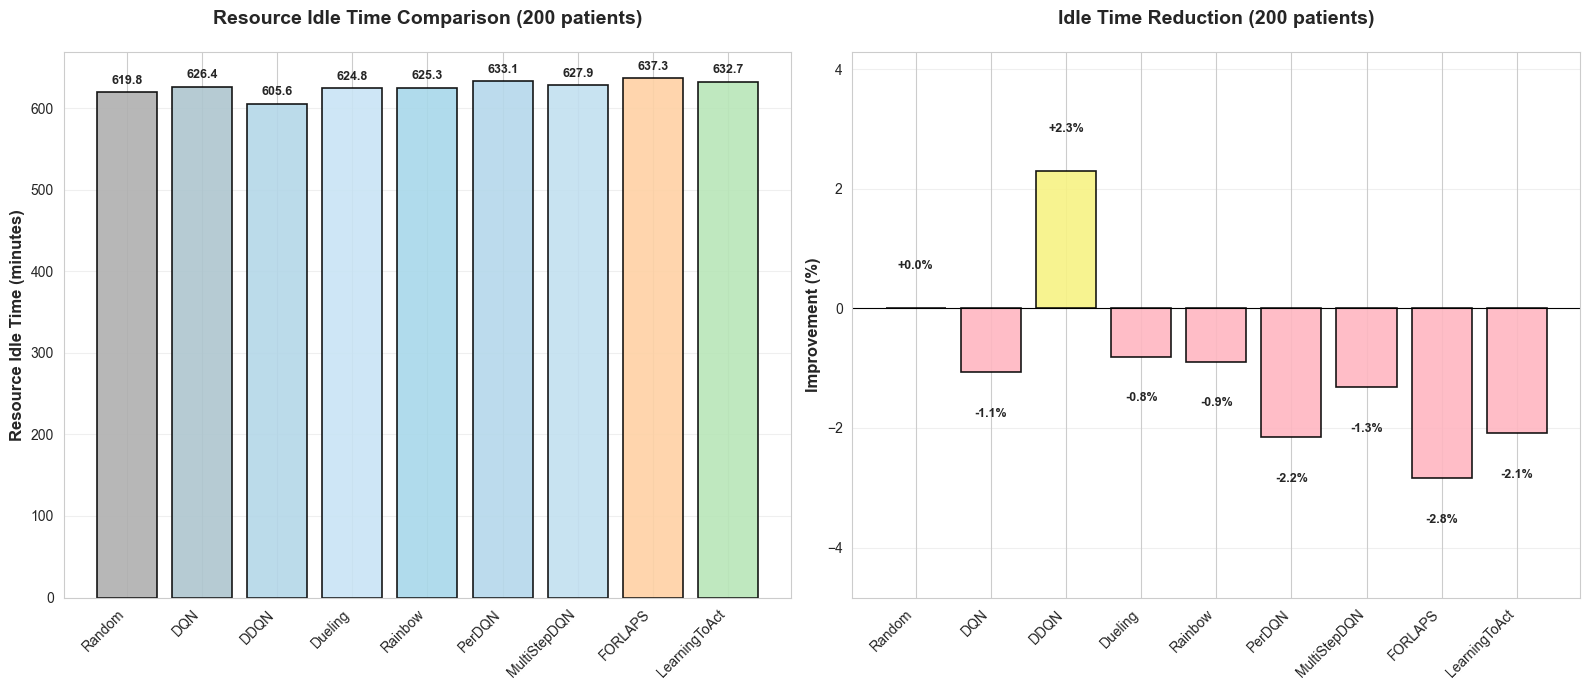

In [5]:
# Chạy cho 200 bệnh nhân
df_200 = visualize_idle_time_comparison(num_patients=200)


RESOURCE IDLE TIME CHO 250 BỆNH NHÂN

📊 Random:
   Average Idle Time per Resource: 771.58
   Idle Time per Activity:
      Registration                       :  3677.00
      Payment                            :  1567.00
      Get Triage Number                  :  1042.00
      Measure Vital Signs                :  2626.00
      General Medicine Examination       :  3427.00
      Eye Examination                    :  1328.00
      ENT Examination                    :  1335.00
      Dental Examination                 :  1339.00
      Gynecological Examination          :  1627.00
      Breast Examination                 :  1505.00
      Blood Test                         :  3954.00
      Urine Test                         :   844.00
      In-depth Eye Examination           :  1042.00
      ENT Endoscopy                      :  1042.00
      Electrocardiogram (ECG)            :  3126.00
      Post-bronchodilator Spirometry     :  1042.00
      General Ultrasound                 :  2173.0

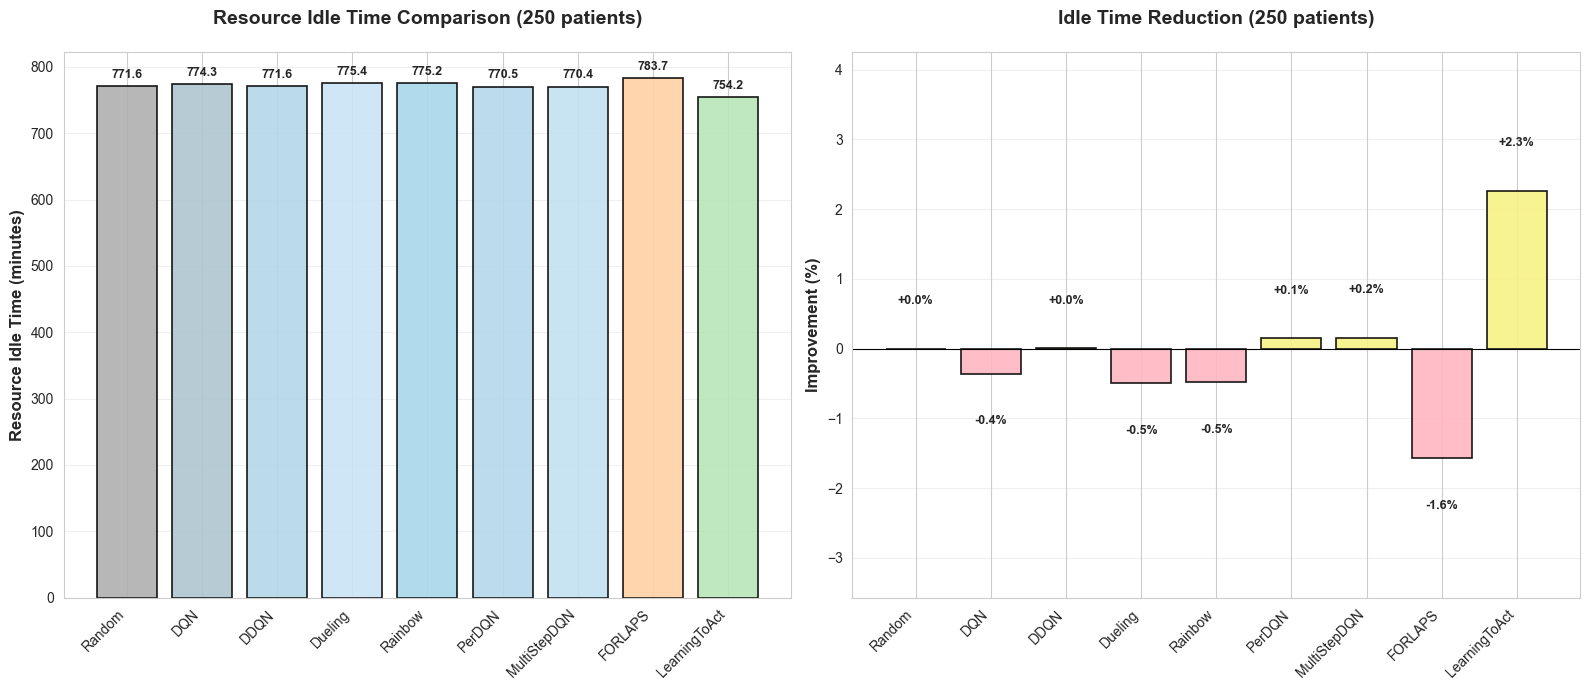

In [6]:
# Chạy cho 250 bệnh nhân
df_250 = visualize_idle_time_comparison(num_patients=250)


RESOURCE IDLE TIME CHO 300 BỆNH NHÂN

📊 Random:
   Average Idle Time per Resource: 907.78
   Idle Time per Activity:
      Registration                       :  4344.00
      Payment                            :  1847.00
      Get Triage Number                  :  1233.00
      Measure Vital Signs                :  3100.00
      General Medicine Examination       :  4038.00
      Eye Examination                    :  1558.00
      ENT Examination                    :  1567.00
      Dental Examination                 :  1573.00
      Gynecological Examination          :  1895.00
      Breast Examination                 :  1765.00
      Blood Test                         :  4657.00
      Urine Test                         :   970.00
      In-depth Eye Examination           :  1233.00
      ENT Endoscopy                      :  1233.00
      Electrocardiogram (ECG)            :  3699.00
      Post-bronchodilator Spirometry     :  1233.00
      General Ultrasound                 :  2539.0

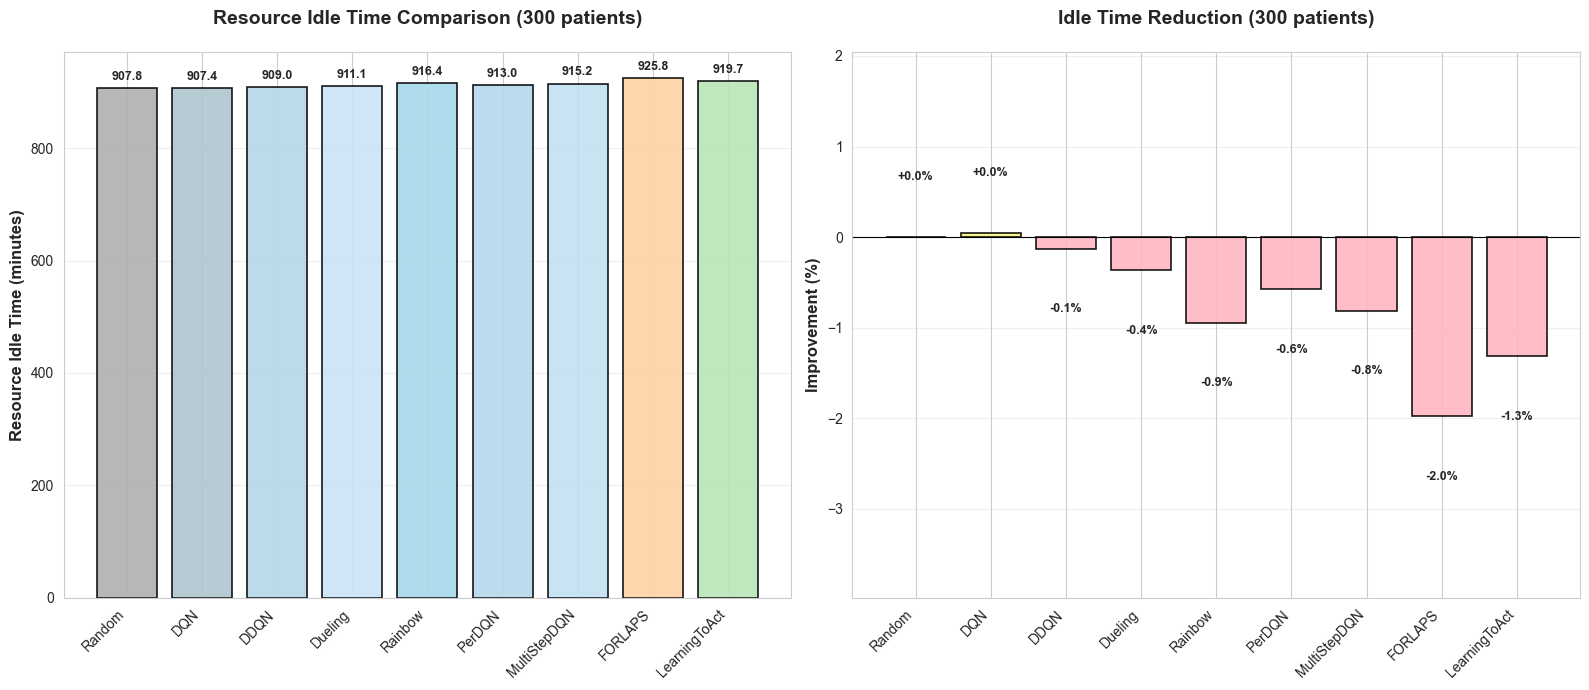

In [7]:
# Chạy cho 300 bệnh nhân
df_300 = visualize_idle_time_comparison(num_patients=300)